In [45]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import fft
from scipy.signal import find_peaks
from scipy.interpolate import interp1d

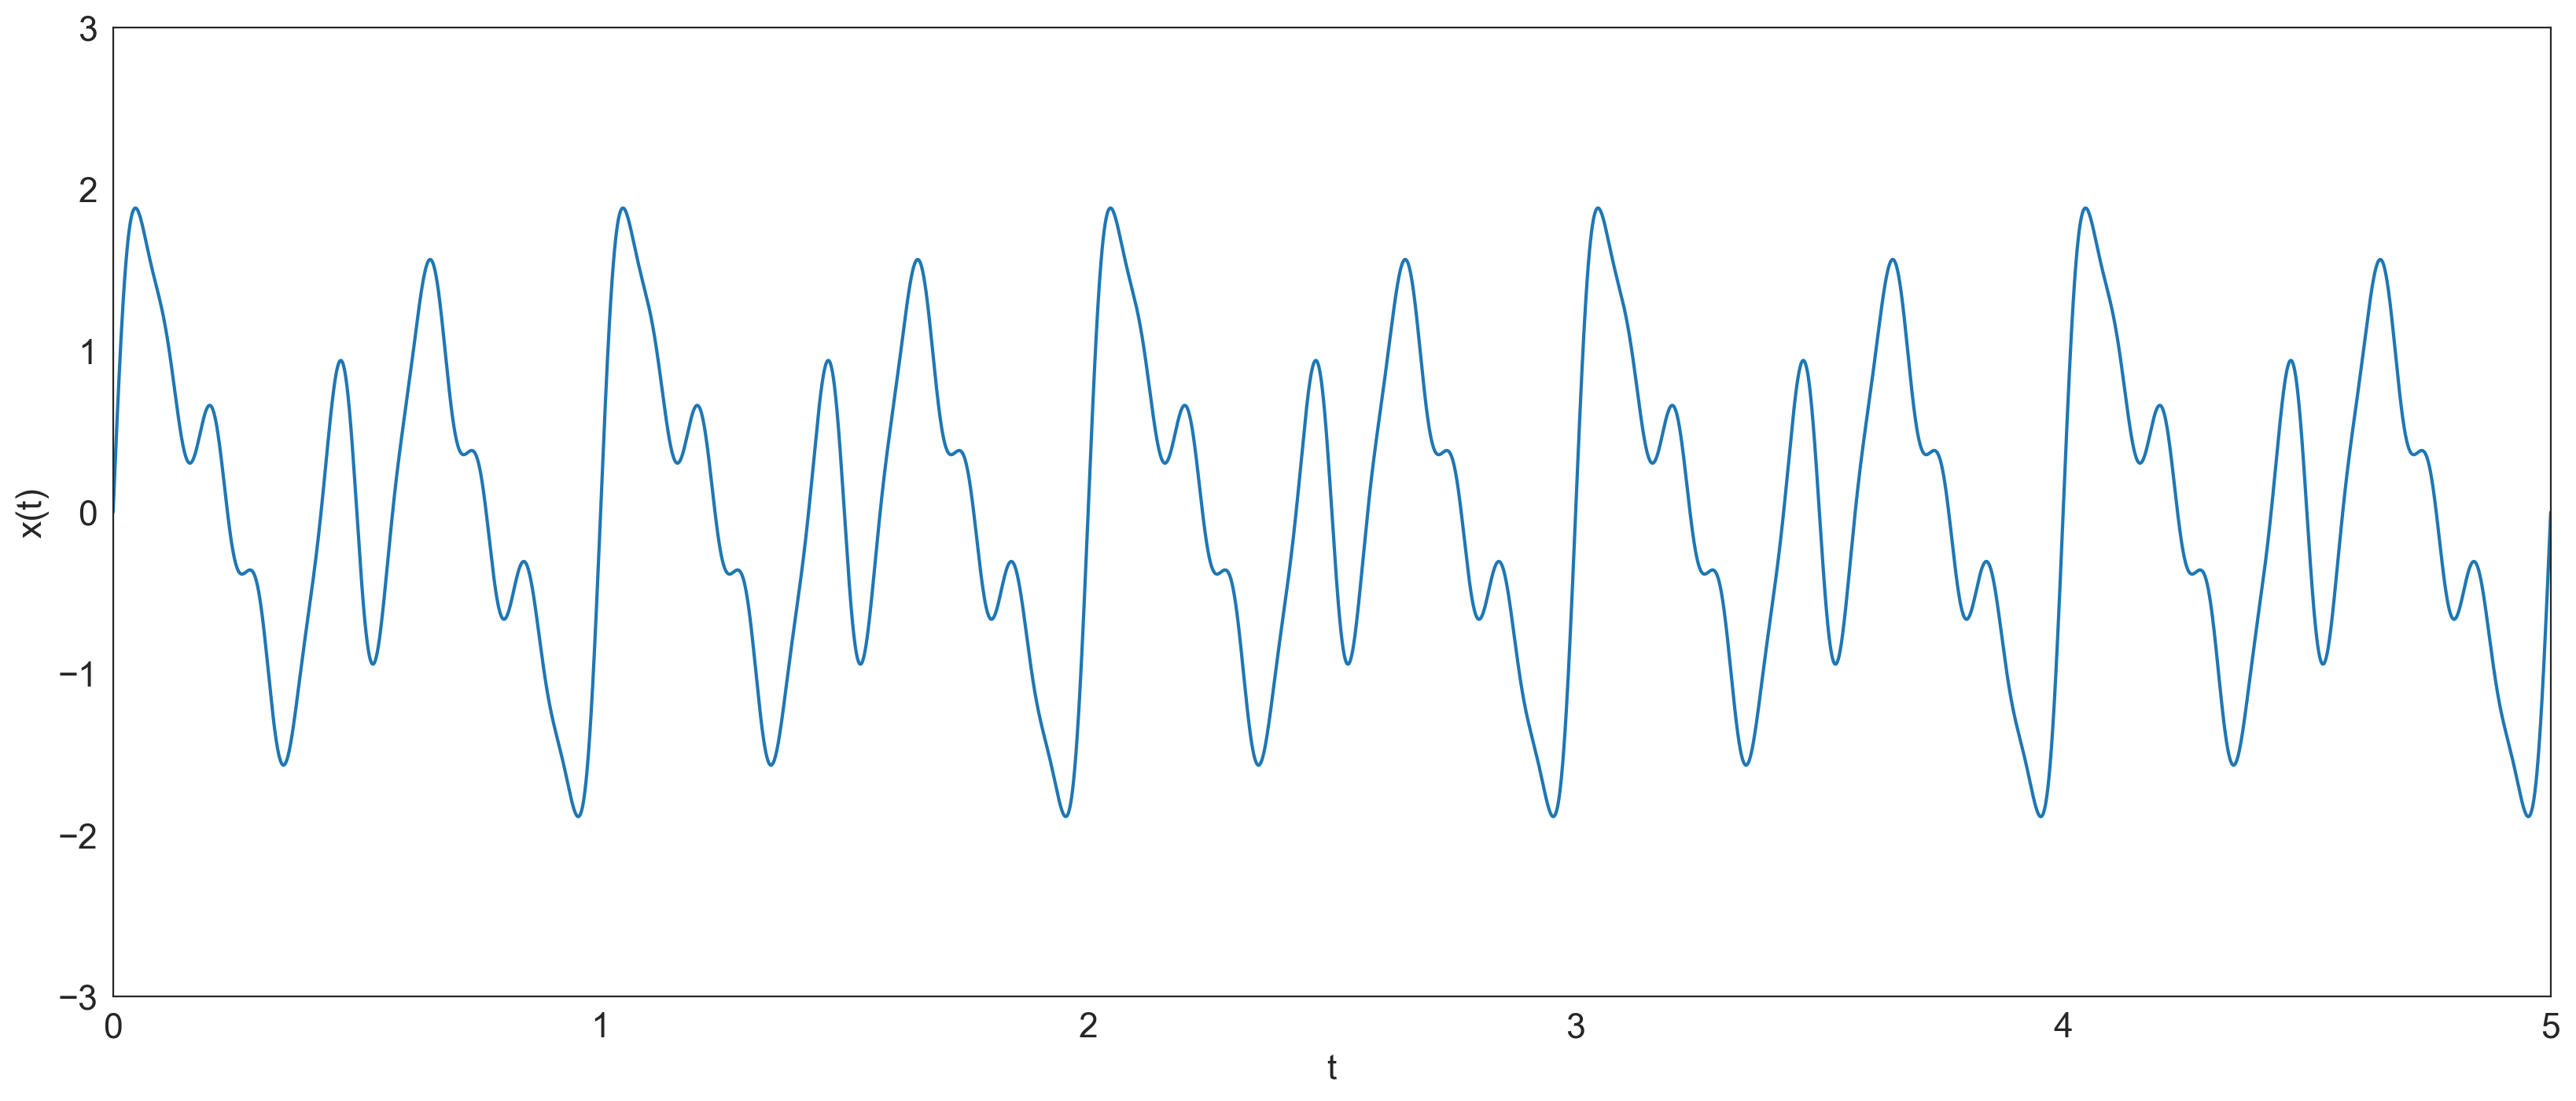

In [90]:
#https://github.com/srcole/binder_emd/blob/master/emd.ipynb
import numpy as np
import matplotlib.pyplot as plt

# Define the frequency components of the signal
f1 = 2  # Hz
f2 = 3  # Hz
f3 = 5  # Hz
f4 = 7  # Hz
f5 = 11 # Hz

# Define the amplitude of each frequency component
a1 = 1
a2 = 0.5
a3 = 0.7
a4 = 0.3
a5 = 0.2

# Define the time array
t = np.linspace(0, 5, 10000)

# Generate the signal by summing the sine waves
y = a1*np.sin(2*np.pi*f1*t) + a2*np.sin(2*np.pi*f2*t) + a3*np.sin(2*np.pi*f3*t) + a4*np.sin(2*np.pi*f4*t) + a5*np.sin(2*np.pi*f5*t)

# Plot the signal
plt.figure(figsize = (20,8))
plt.plot(t, y)
plt.xlabel('t')
plt.ylabel('x(t)')
plt.xlim(0,5)
plt.ylim(-3,3)
plt.savefig('EMDrawsignal.pdf',bbox_inches='tight')
plt.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


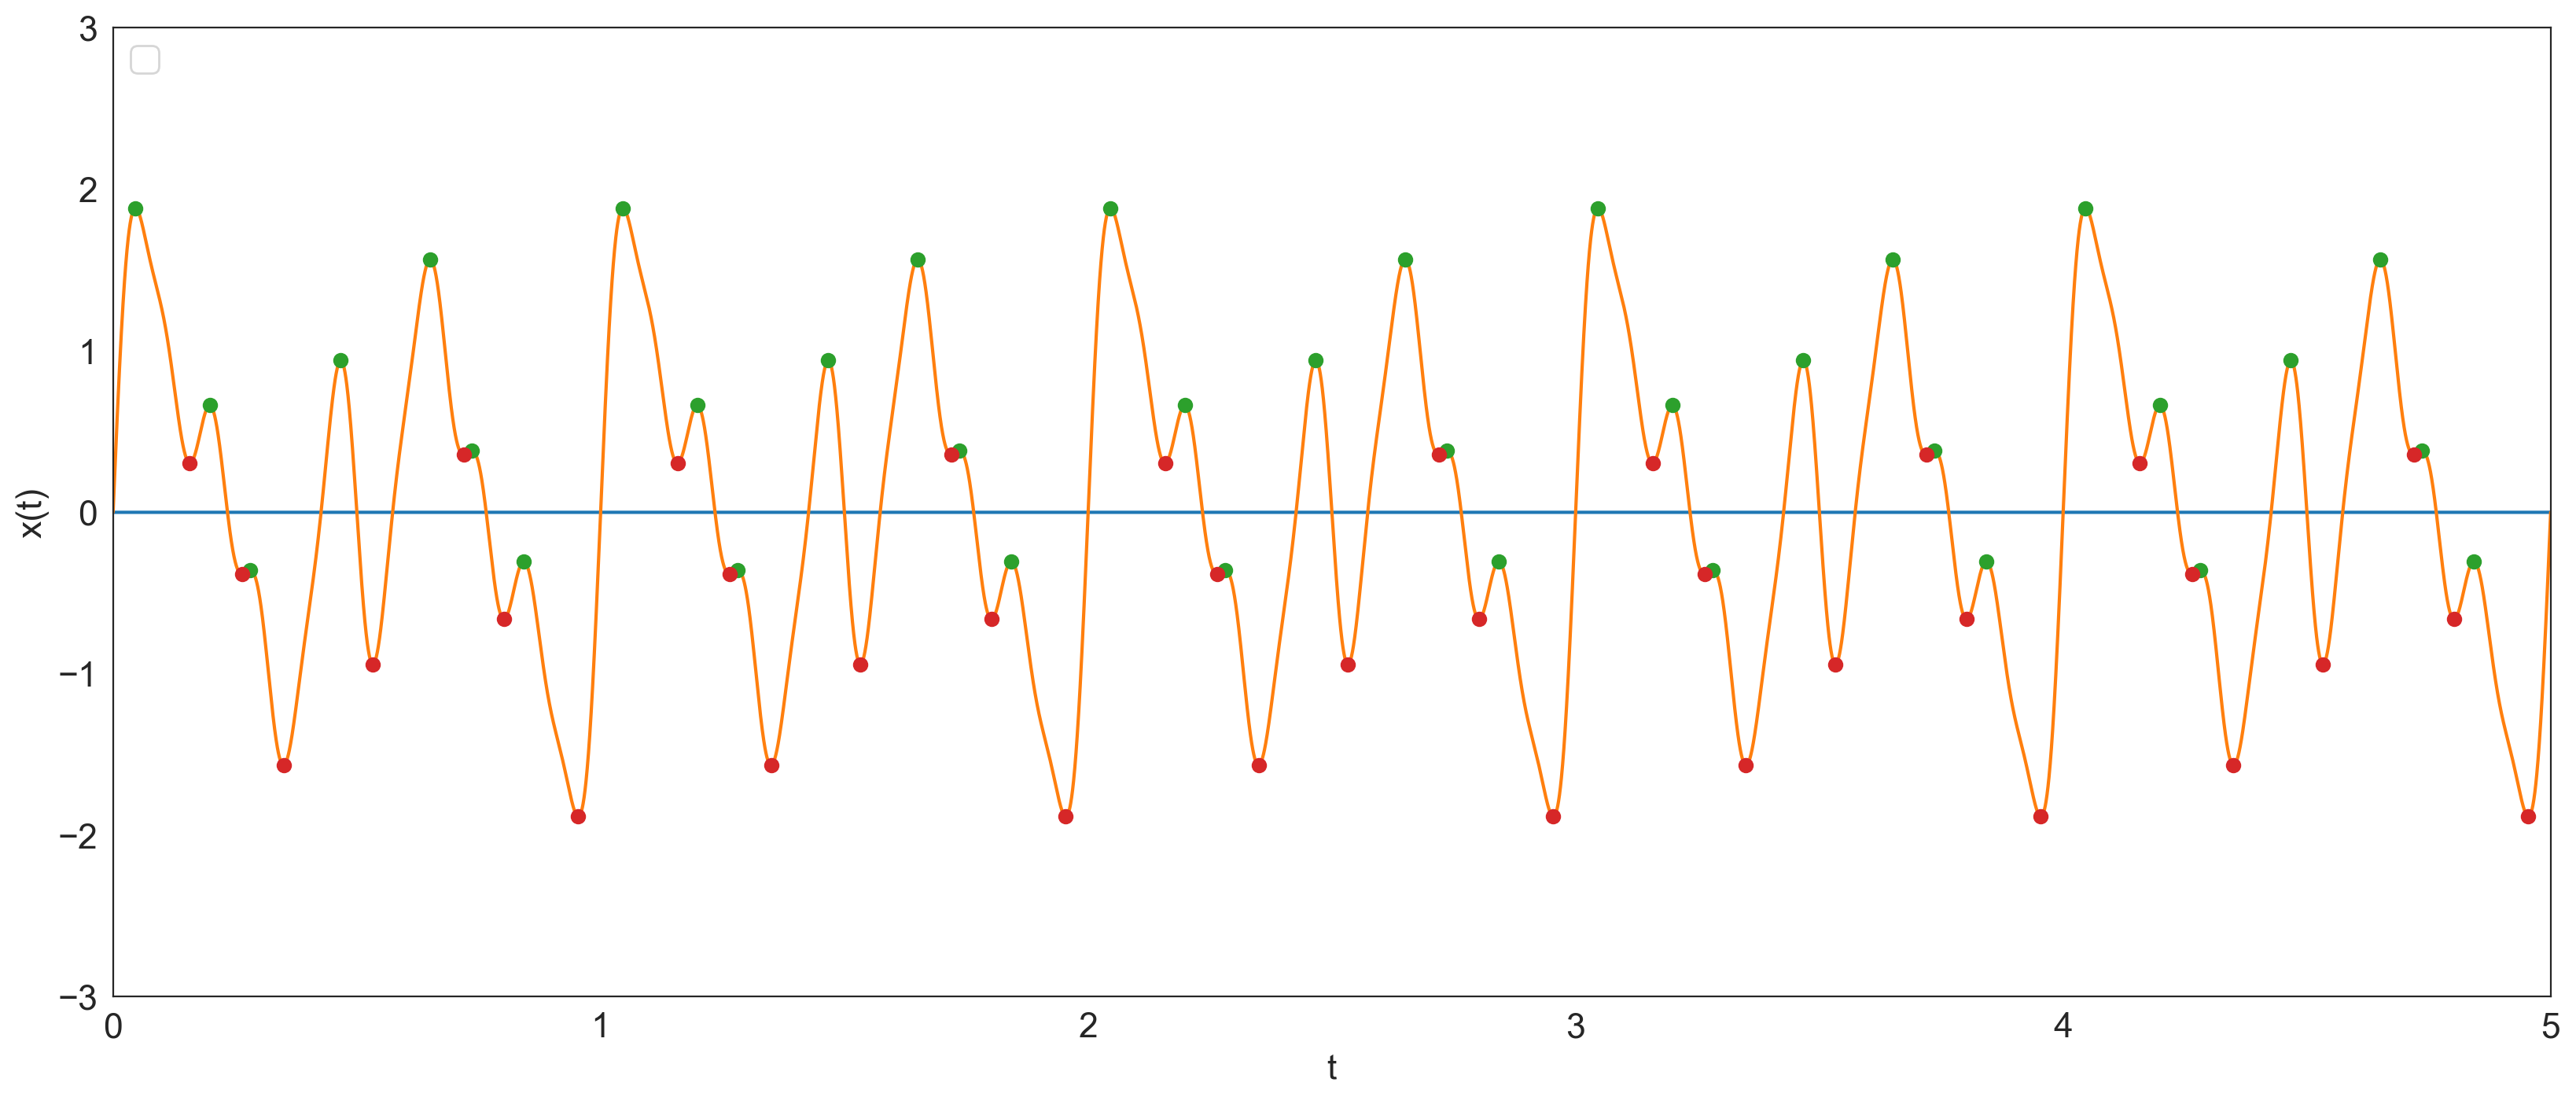

In [91]:
x=y
upper_peaks, _ = find_peaks(x)
lower_peaks, _ = find_peaks(-x)

plt.rcParams.update({'font.size' : 16})
plt.figure(figsize = (20,8))
plt.xlabel('t')
plt.ylabel('x(t)')
plt.legend(loc = 'upper left')
plt.xlim(0,5)
plt.ylim(-3,3)
plt.plot(t,np.zeros_like(t))
plt.plot(t,x)
plt.plot(t[upper_peaks],x[upper_peaks],'o',label = 'Upper peaks')
plt.plot(t[lower_peaks],x[lower_peaks],'o',label = 'Lower peaks')
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


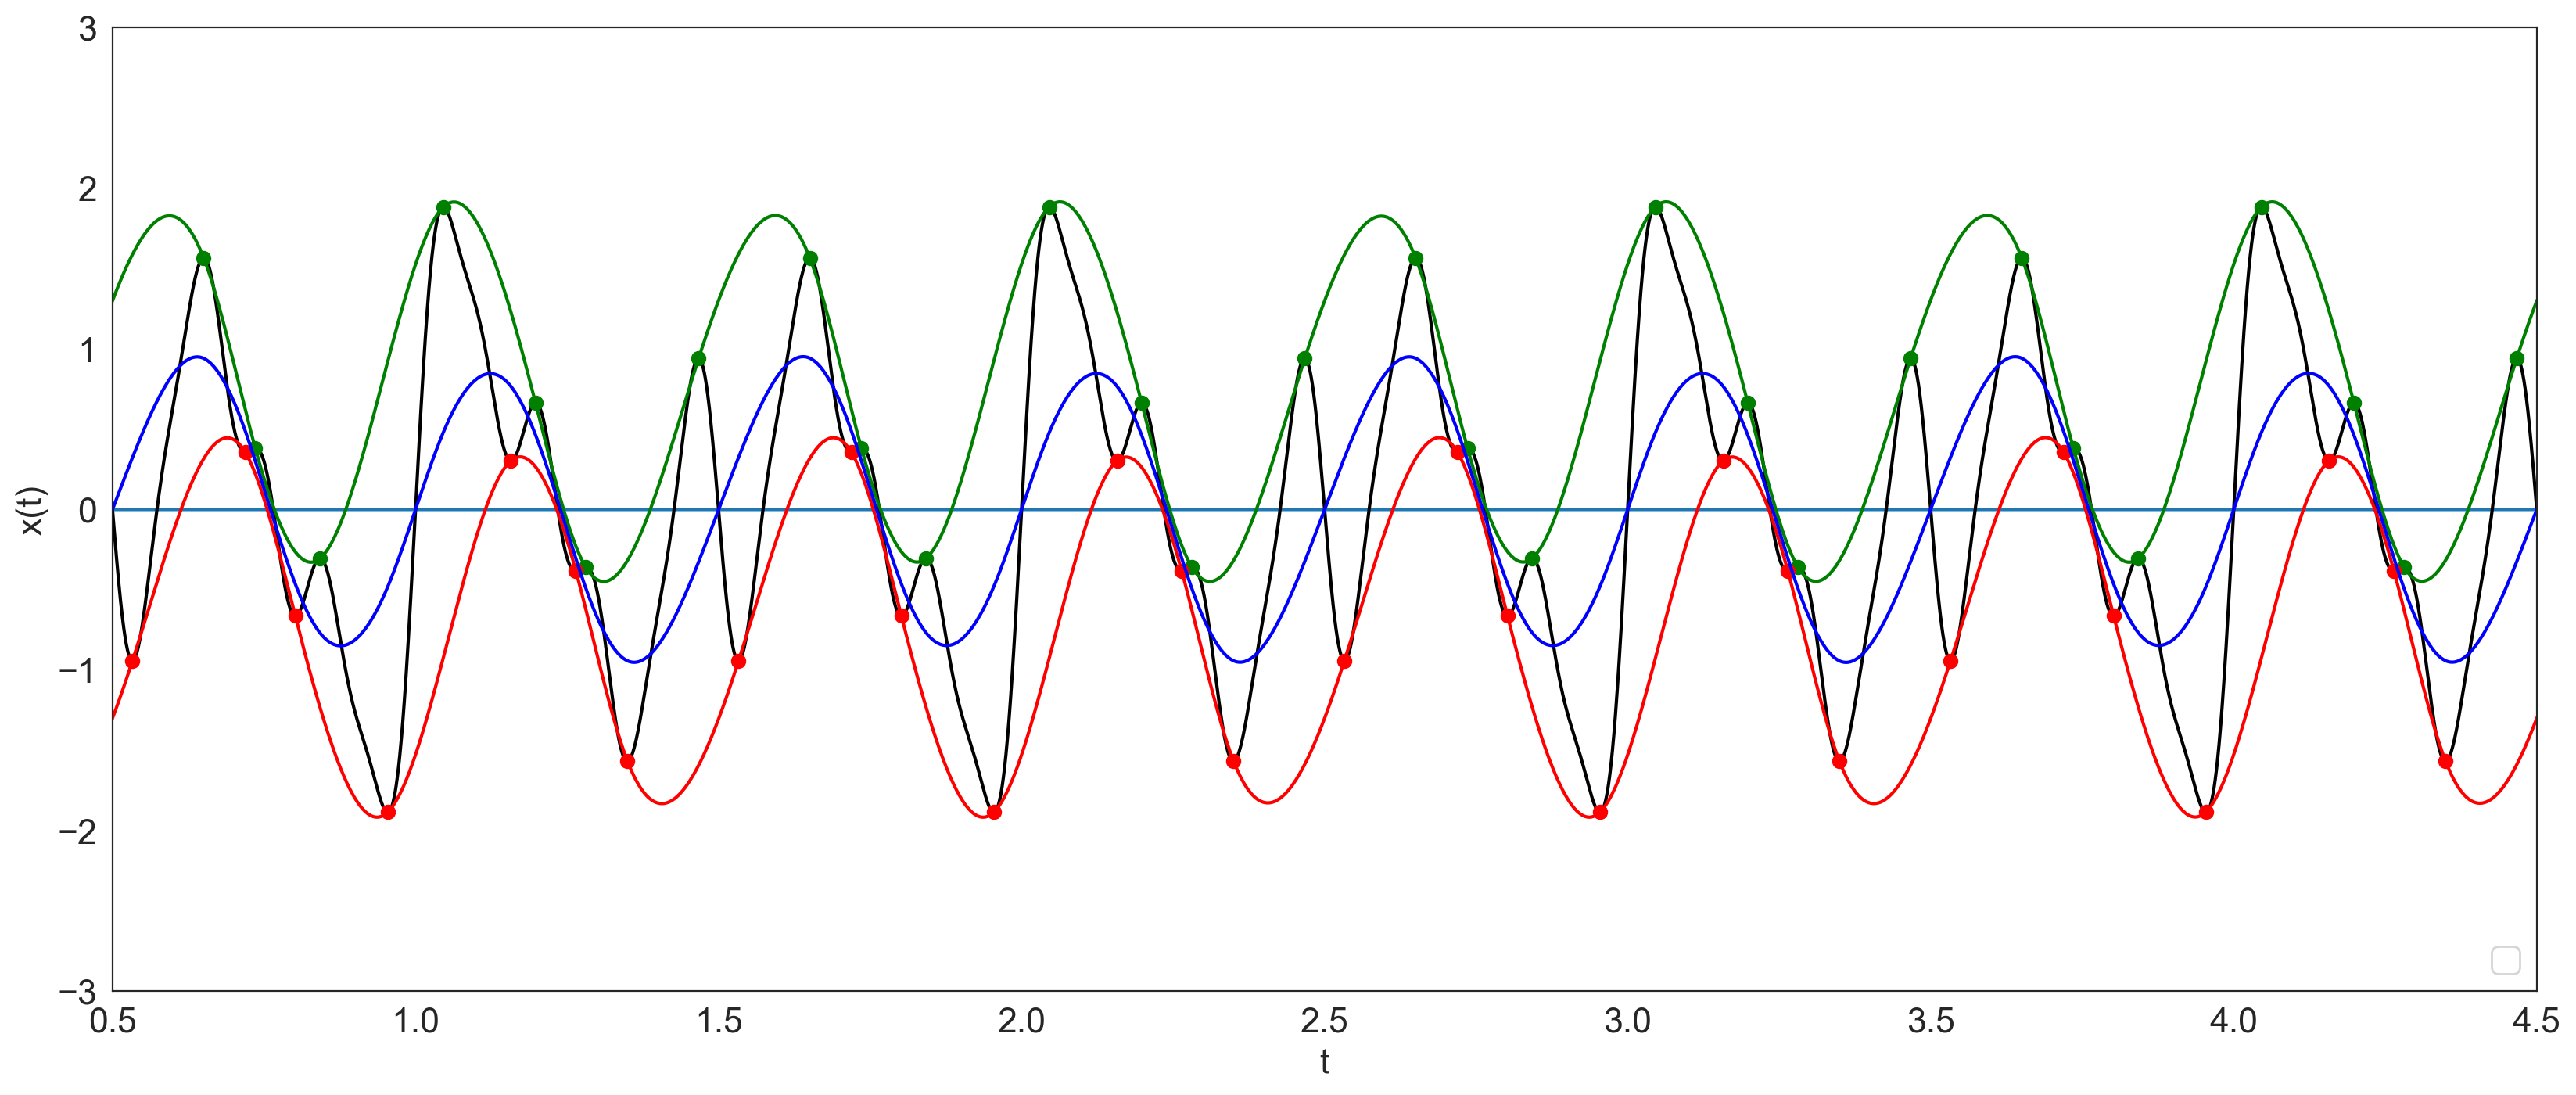

In [93]:
u = interp1d(t[upper_peaks],x[upper_peaks], kind = 'cubic', fill_value = 'extrapolate')
l = interp1d(t[lower_peaks],x[lower_peaks], kind = 'cubic', fill_value = 'extrapolate')

y1 = u(t)
y2 = l(t)

# Zero padding to avoid singularities at the edges of the signal
y1[0:5] = 0
y1[-5:] = 0
y2[0:5] = 0
y2[-5:] = 0
mu = (y1 + y2) / 2


plt.figure(figsize = (20,8))
plt.plot(t,np.zeros_like(t))
plt.ylim(-3,3)
plt.xlim(0.5,4.5)
plt.ylabel('x(t)')
plt.xlabel('t')
plt.legend(loc = 'lower right')
plt.plot(t,x, label = 'signal',color='black')
#plt.savefig('EMDRawSignal.pdf',bbox_inches='tight')
plt.plot(t[upper_peaks],x[upper_peaks],'o',label = 'Upper peaks',color='g')
#plt.savefig('EMDUperPeaks.pdf',bbox_inches='tight')
plt.plot(t,y1, label = 'upper envelope',color='g')
#plt.savefig('EMDUperEnvelop.pdf',bbox_inches='tight')
plt.plot(t[lower_peaks],x[lower_peaks],'o',label = 'Lower peaks',color='r')
#plt.savefig('EMDLowerPeaks.pdf',bbox_inches='tight')
plt.plot(t,y2, label = 'lower envelope',color='r')
#plt.savefig('EMDLowerEnvelop.pdf',bbox_inches='tight')
plt.plot(t,mu, label = 'average envelope', color='b')
#plt.savefig('EMDUperLowerEnvelopMean.pdf',bbox_inches='tight')
plt.show()

Text(0.5, 0, 't')

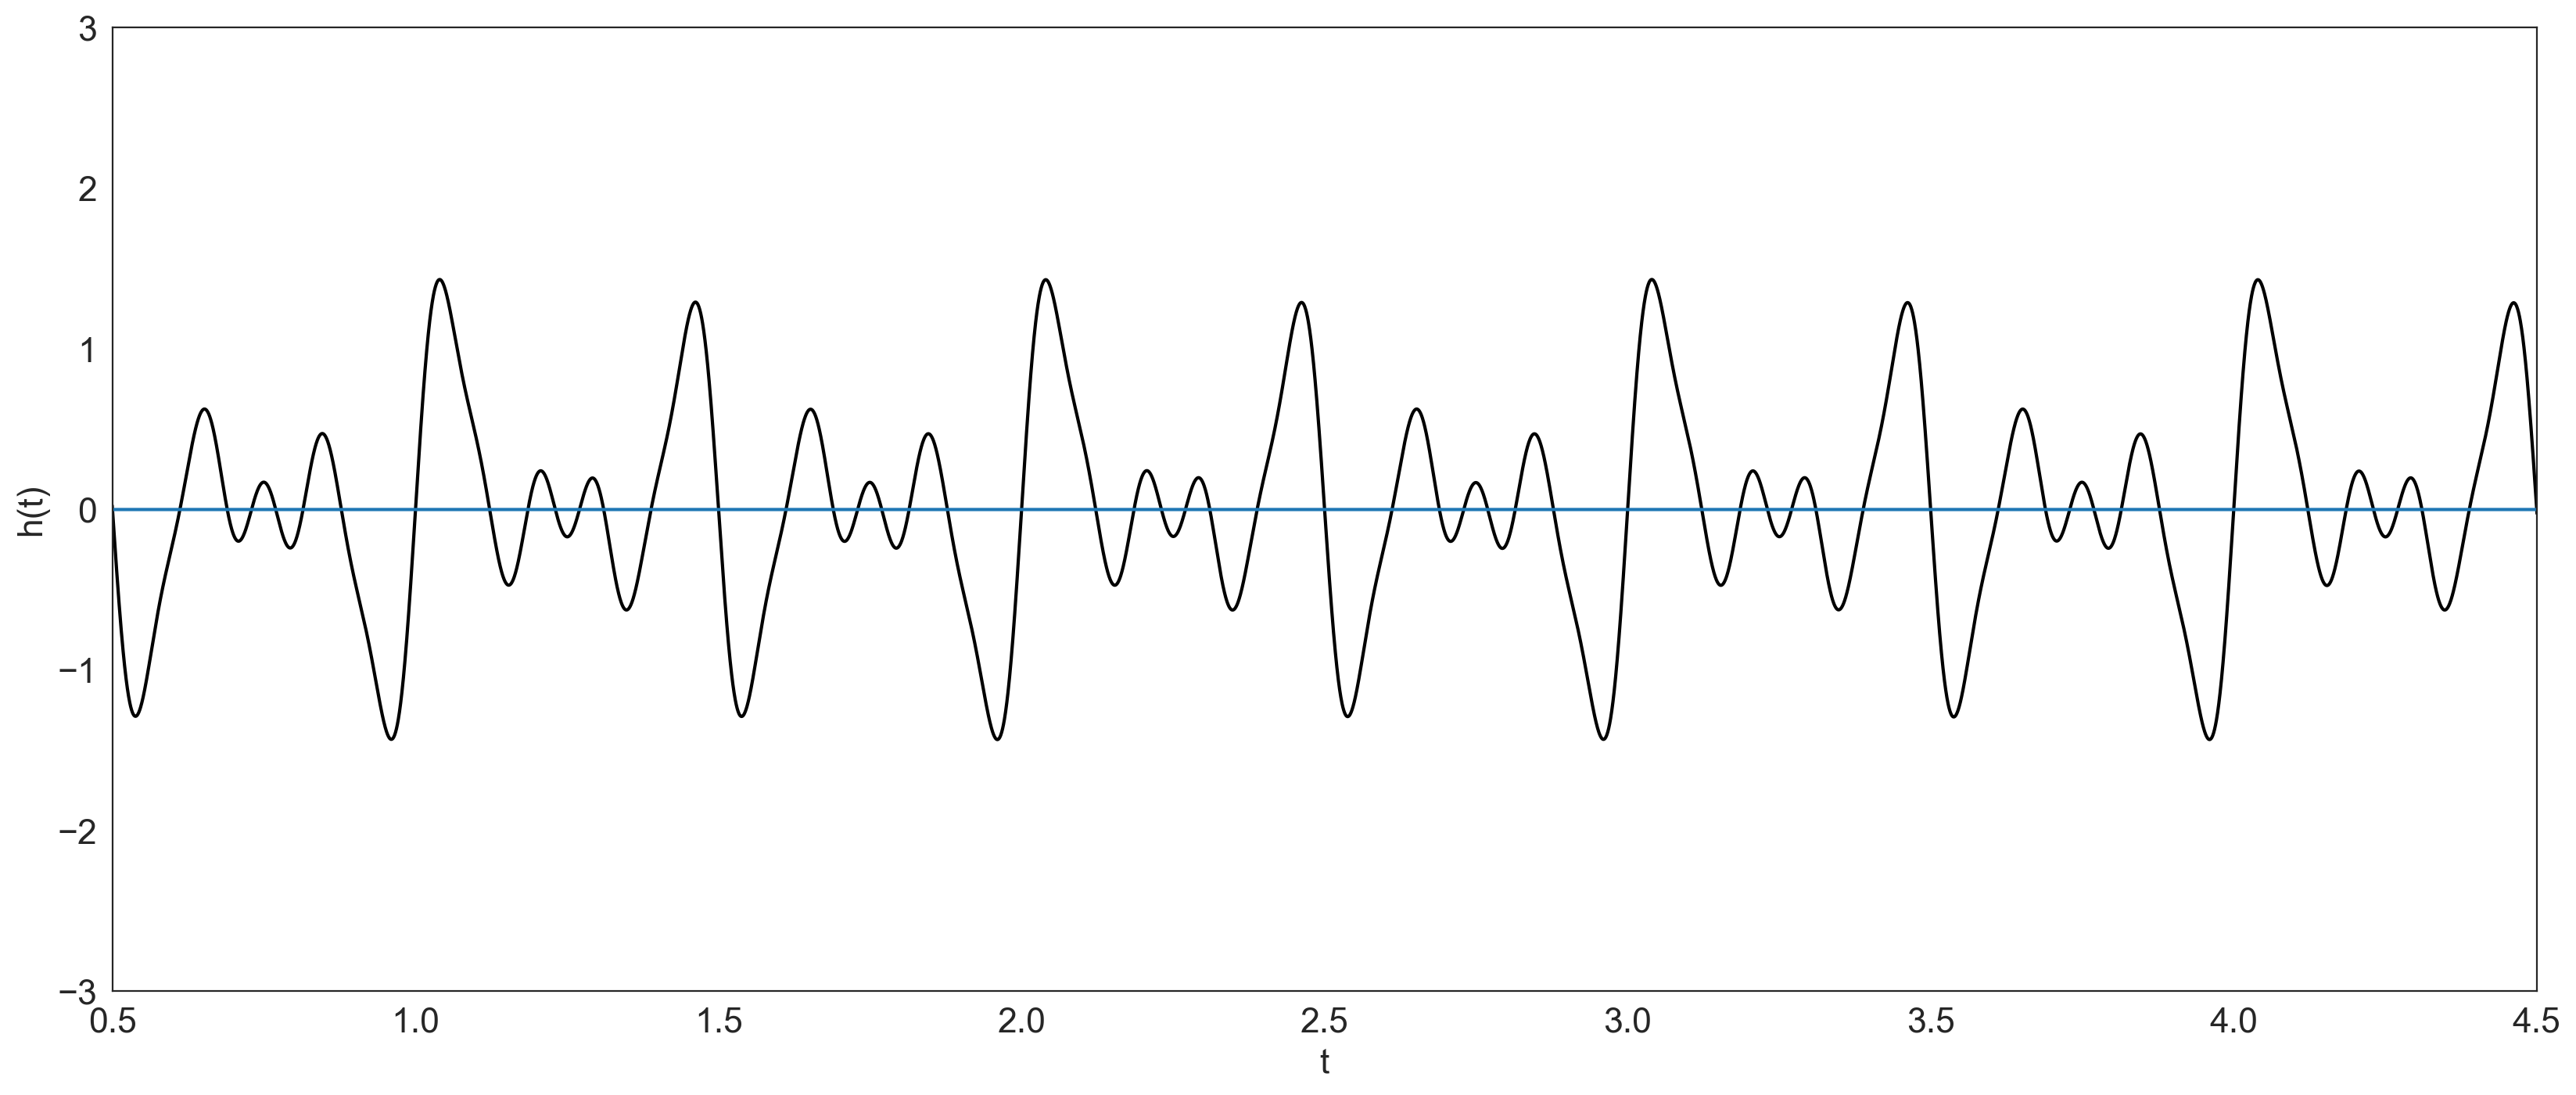

In [85]:
h=x-mu
plt.figure(figsize = (20,8))
plt.plot(t,h, label = 'mu',color='black')
plt.plot(t,np.zeros_like(t))
plt.ylim(-3,3)
plt.xlim(0.5,4.5)
plt.ylabel('h(t)')
plt.xlabel('t')

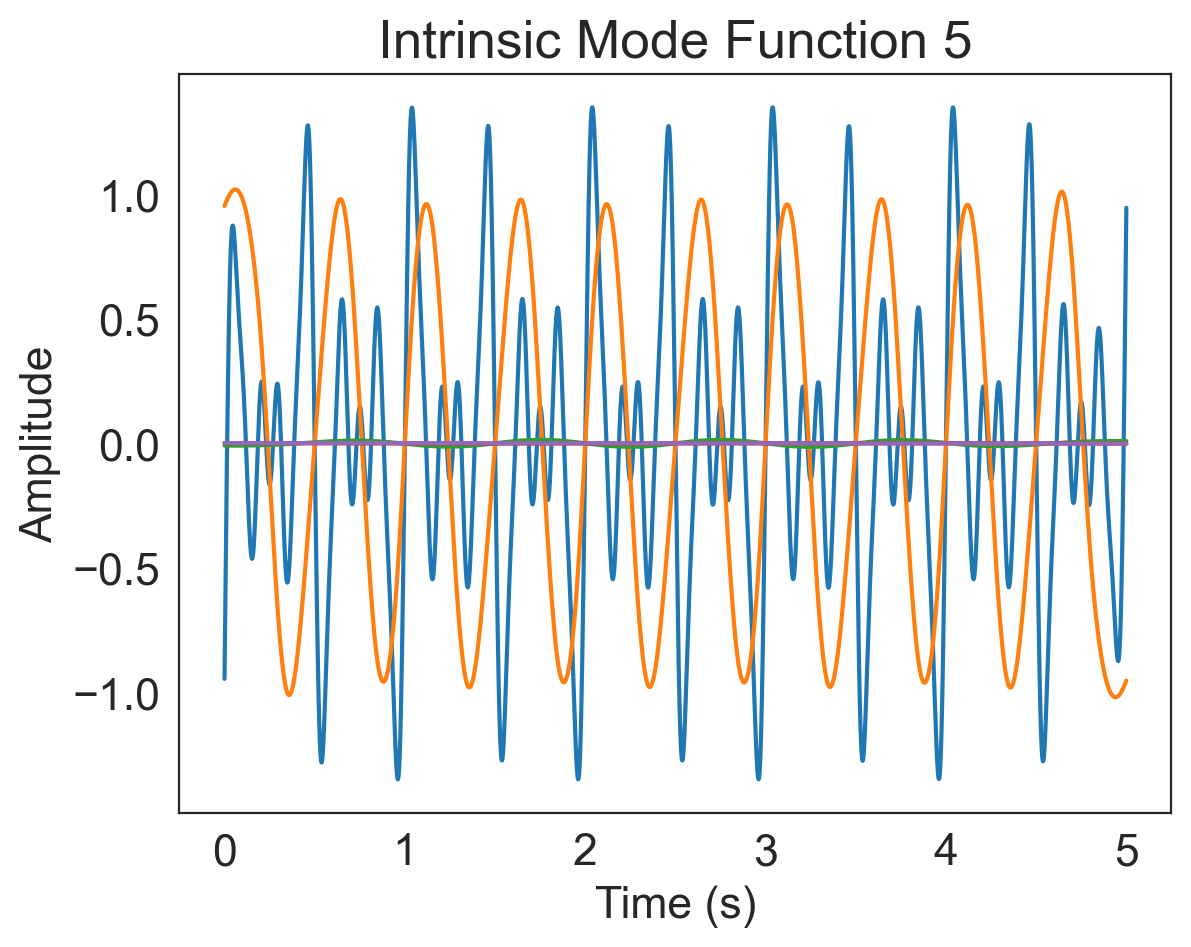

In [94]:
from PyEMD import EMD
# Decompose the signal into IMFs using the EMD algorithm
emd=EMD()
imfs = emd.emd(y)

# Plot the IMFs
for i in range(imfs.shape[0]):
    plt.plot(t, imfs[i,:])
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.title('Intrinsic Mode Function %d' % (i+1))
plt.show()


In [24]:
%config InlineBackend.figure_format = 'retina'
%matplotlib inline
import seaborn as sns
sns.set_style('white')

import numpy as np
import scipy as sp
from scipy import signal
import matplotlib.pyplot as plt

In [25]:
def emd(x, nIMF = 3, stoplim = .001):
    """Perform empirical mode decomposition to extract 'niMF' components out of the signal 'x'."""
    
    r = x
    t = np.arange(len(r))
    imfs = np.zeros(nIMF,dtype=object)
    for i in range(nIMF):
        r_t = r
        is_imf = False
        
        while is_imf == False:
            # Identify peaks and troughs
            pks = sp.signal.argrelmax(r_t)[0]
            trs = sp.signal.argrelmin(r_t)[0]
            
            # Interpolate extrema
            pks_r = r_t[pks]
            fip = sp.interpolate.InterpolatedUnivariateSpline(pks,pks_r,k=3)
            pks_t = fip(t)
            
            trs_r = r_t[trs]
            fitr = sp.interpolate.InterpolatedUnivariateSpline(trs,trs_r,k=3)
            trs_t = fitr(t)
            
            # Calculate mean
            mean_t = (pks_t + trs_t) / 2
            mean_t = _emd_complim(mean_t, pks, trs)
            
            # Assess if this is an IMF (only look in time between peaks and troughs)
            sdk = _emd_comperror(r_t, mean_t, pks, trs)
            
            # if not imf, update r_t and is_imf
            if sdk < stoplim:
                is_imf = True
            else:
                r_t = r_t - mean_t
                
        
        imfs[i] = r_t
        r = r - imfs[i] 
        
    return imfs


def _emd_comperror(h, mean, pks, trs):
    """Calculate the normalized error of the current component"""
    samp_start = np.max((np.min(pks),np.min(trs)))
    samp_end = np.min((np.max(pks),np.max(trs))) + 1
    return np.sum(np.abs(mean[samp_start:samp_end]**2)) / np.sum(np.abs(h[samp_start:samp_end]**2))


def _emd_complim(mean_t, pks, trs):
    samp_start = np.max((np.min(pks),np.min(trs)))
    samp_end = np.min((np.max(pks),np.max(trs))) + 1
    mean_t[:samp_start] = mean_t[samp_start]
    mean_t[samp_end:] = mean_t[samp_end]
    return mean_t

In [26]:
#minN = 7000
#maxN = 9000
x = y
#x = x[minN:maxN+1]
#t = np.arange(0,len(x)*.001,.001) 

In [27]:
imfs = emd(x, nIMF = 5)

C:\Users\adil\AppData\Local\Temp\ipykernel_28680\326651300.py:7: DeprecationWarning: `np.str` is a deprecated alias for the builtin `str`. To silence this warning, use `str` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.str_` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  plt.ylabel('IMF '+np.str(i+1))


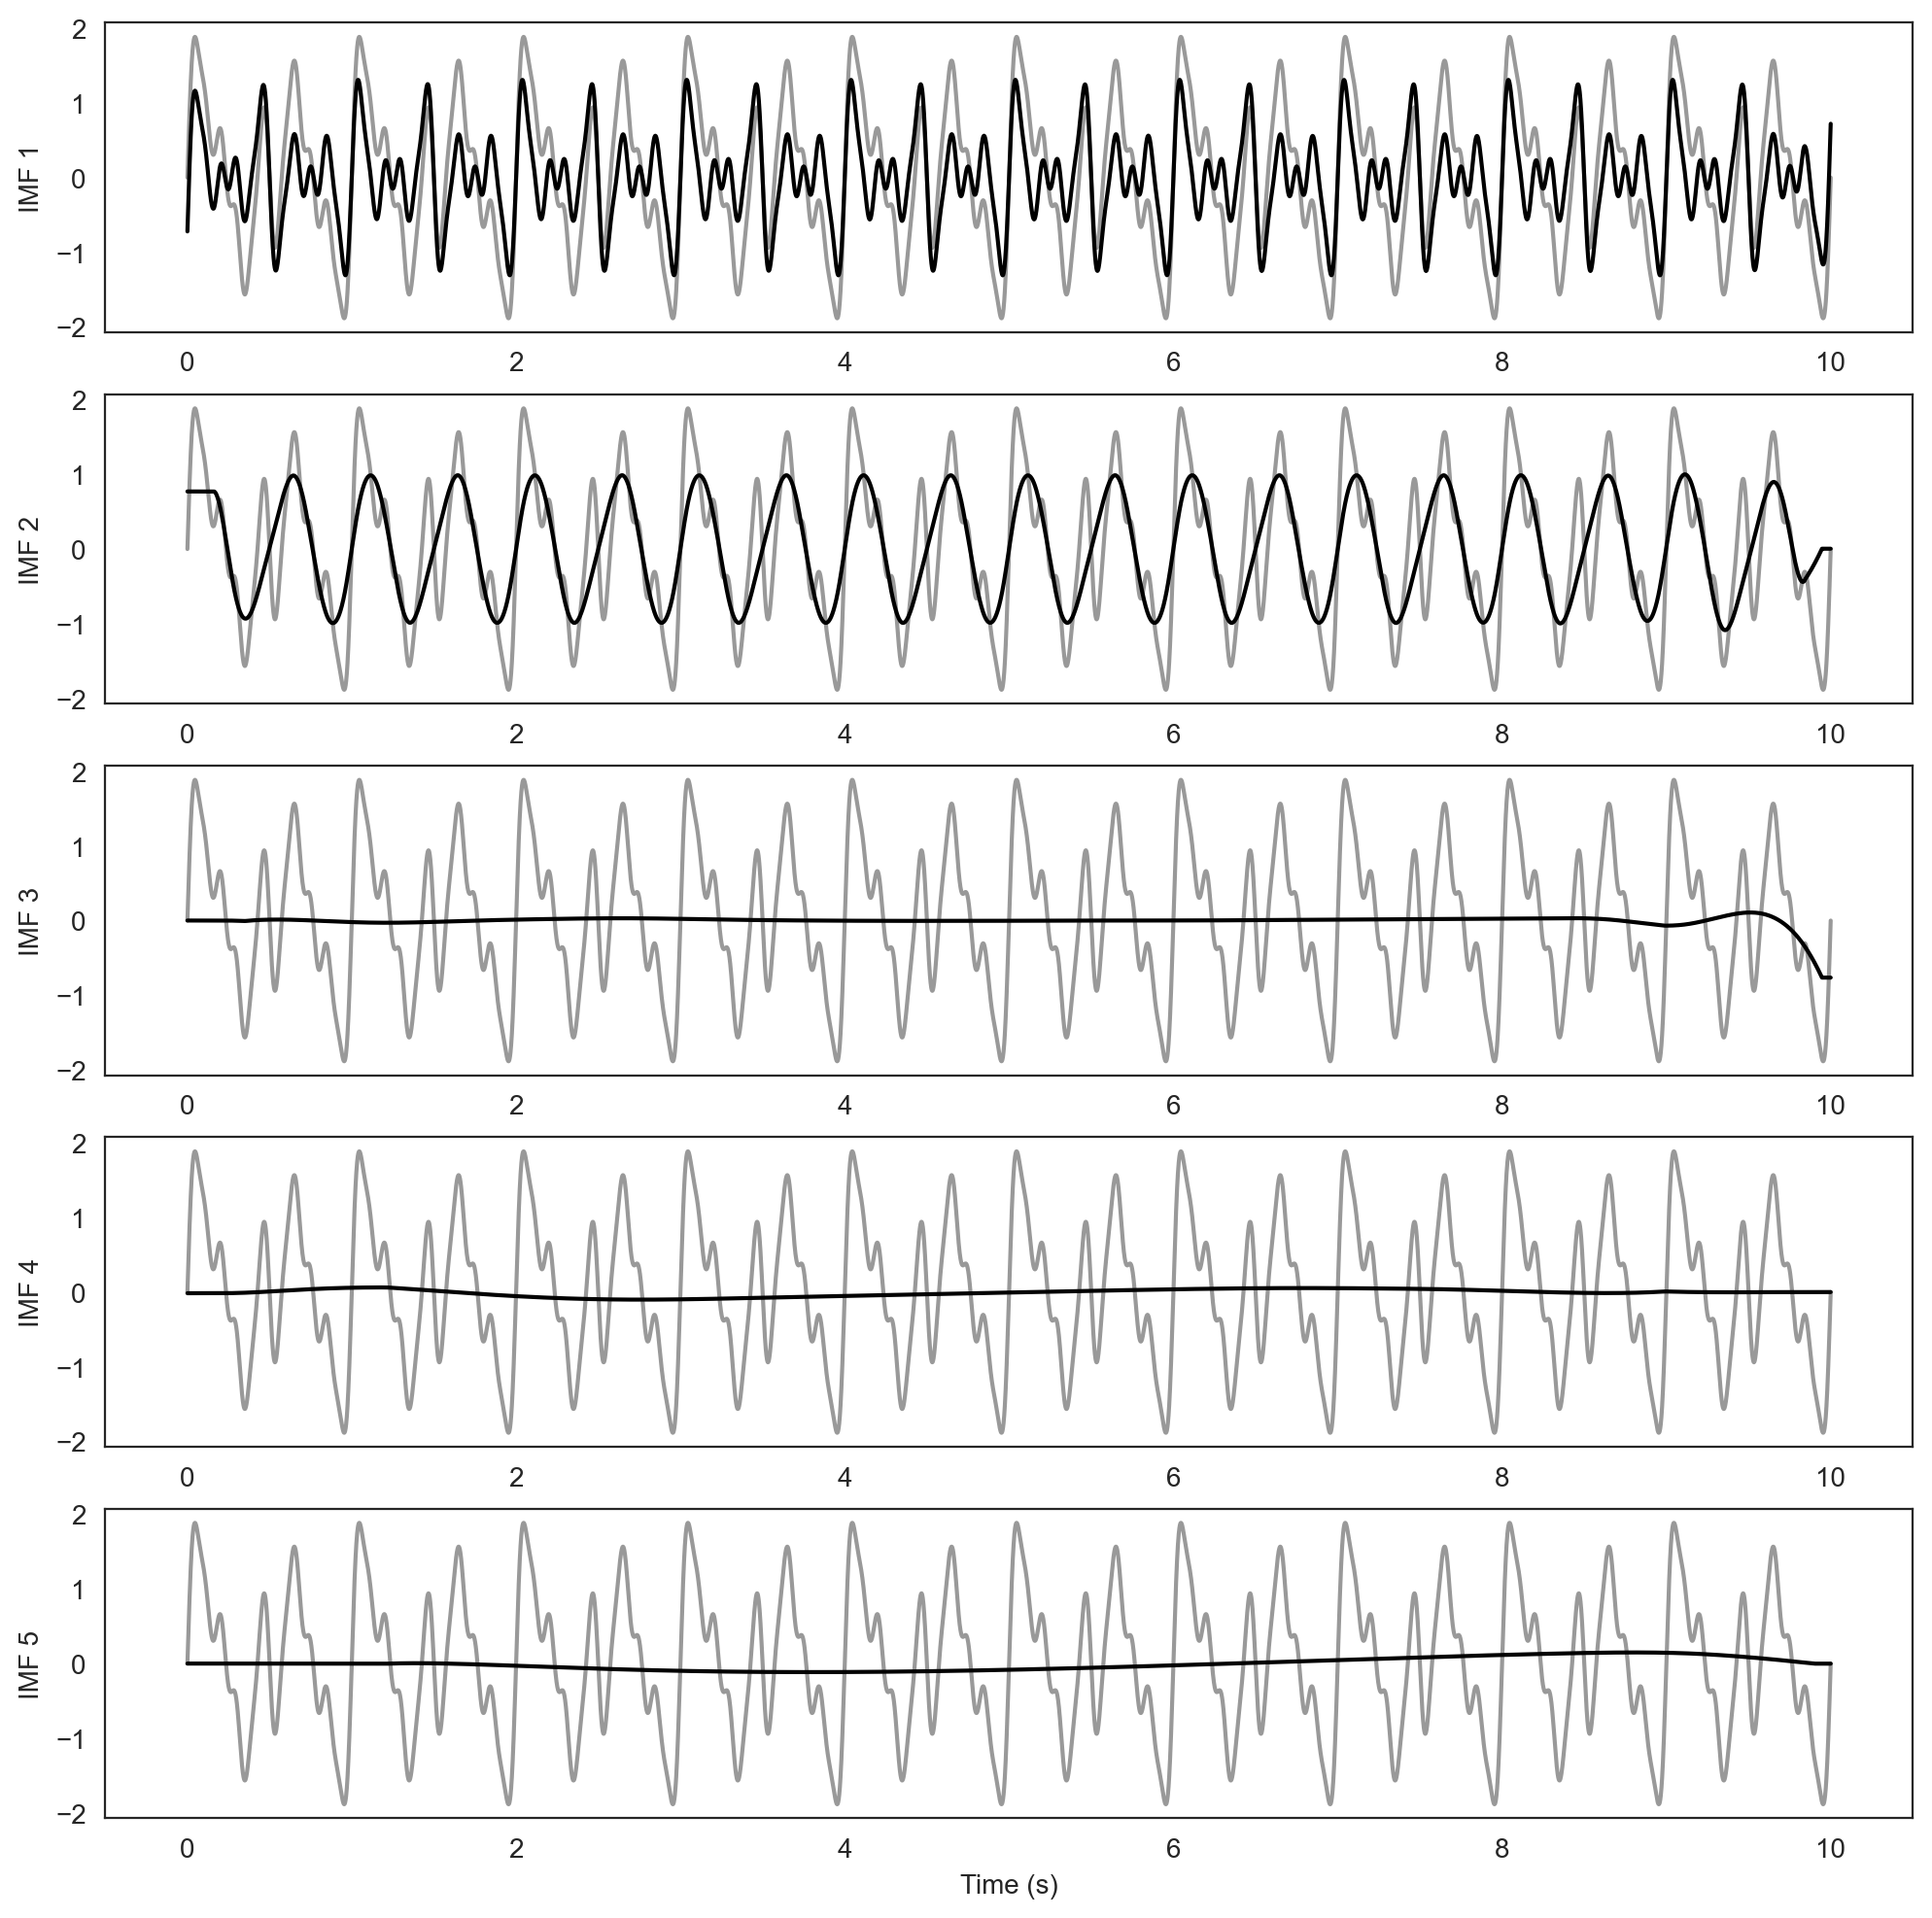

In [28]:
plt.figure(figsize=(12,12))
for i in range(len(imfs)):
    plt.subplot(len(imfs),1,i+1)
    plt.plot(t,x,color='0.6')
    plt.plot(t,imfs[i],'k')
    #plt.ylim([-2,2])
    plt.ylabel('IMF '+np.str(i+1))
    if i == len(imfs)-1:
        plt.xlabel('Time (s)')